In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [10]:
#define state
class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [12]:
def calculate_bmi(state: BMIState) -> BMIState:
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

def lable_bmi(state: BMIState) -> BMIState:
    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = "underweight"
    elif 18.5 < bmi <25:
        state['category'] = "Normal"
    elif 25 <= bmi < 30:
        state['category'] = "Overweight"
    else:
        state['category'] = "Obese"

    return state

In [13]:
#define your graph
graph = StateGraph(BMIState)

#add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('lable_bmi', lable_bmi)

#add edges to your graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', 'lable_bmi')
graph.add_edge('lable_bmi', END)

#compile the graph
workflow = graph.compile()

In [15]:
#execute the graph
initial_state = {'weight_kg':80, 'height_m':1.73}
output_state = workflow.invoke(initial_state)
print(output_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


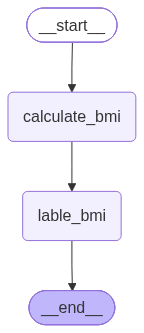

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())